# Explore MassSpecGym Complete Dataset

This notebook explores the MassSpecGym complete dataset including:
- **Embeddings** (.npy files)
- **HDF5 spectra** (.hdf5 files)
- **mzML files** (mass spectrometry data)

## Goals
1. Load and inspect embeddings
2. Read and visualize HDF5 spectra
3. Parse mzML files (if needed)
4. Understand the data structure
5. Basic visualization and statistics

## Setup and Imports

In [28]:
import sys
from pathlib import Path

# Add src to path
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful")

✅ Imports successful


## 1. Dataset Overview

In [29]:
# Define paths
DATA_DIR = Path("../data/raw/massspecgym_complete")

# Check what's available
print("📂 Dataset structure:")
print(f"  - HDF5 files: {len(list((DATA_DIR / 'val_hdf5').glob('*.hdf5')))}")
print(f"  - Embeddings: {len(list((DATA_DIR / 'val_embs').glob('*.npy')))}")
print(f"  - mzML files: {len(list((DATA_DIR / 'val_conv').glob('*.mzML')))}")

📂 Dataset structure:
  - HDF5 files: 24
  - Embeddings: 24
  - mzML files: 24


In [30]:
# Load metadata
metadata_path = DATA_DIR / "dataset_metadata.json"
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print("\n📋 Dataset Metadata:")
    print(json.dumps(metadata, indent=2))
else:
    print("⚠️ No metadata file found")


📋 Dataset Metadata:
{
  "dataset_name": "MassSpecGym",
  "download_date": "2025-10-14 16:18:51",
  "total_samples": 231104,
  "splits": {
    "val": {
      "num_samples": 231104,
      "num_chunks": 24,
      "chunk_files": [
        "val_chunk_0000.parquet",
        "val_chunk_0001.parquet",
        "val_chunk_0002.parquet",
        "val_chunk_0003.parquet",
        "val_chunk_0004.parquet",
        "val_chunk_0005.parquet",
        "val_chunk_0006.parquet",
        "val_chunk_0007.parquet",
        "val_chunk_0008.parquet",
        "val_chunk_0009.parquet",
        "val_chunk_0010.parquet",
        "val_chunk_0011.parquet",
        "val_chunk_0012.parquet",
        "val_chunk_0013.parquet",
        "val_chunk_0014.parquet",
        "val_chunk_0015.parquet",
        "val_chunk_0016.parquet",
        "val_chunk_0017.parquet",
        "val_chunk_0018.parquet",
        "val_chunk_0019.parquet",
        "val_chunk_0020.parquet",
        "val_chunk_0021.parquet",
        "val_chunk_0022.

## 2. Explore Embeddings

Load and analyze the pre-computed embeddings from `.npy` files.

In [5]:
# Load first chunk of embeddings
emb_files = sorted((DATA_DIR / 'val_embs').glob('*.npy'))
print(f"Found {len(emb_files)} embedding files")

# Load first chunk
emb_chunk_0 = np.load(emb_files[0])
print(f"\n📊 First chunk shape: {emb_chunk_0.shape}")
print(f"   - Number of samples: {emb_chunk_0.shape[0]}")
print(f"   - Embedding dimension: {emb_chunk_0.shape[1]}")
print(f"   - Data type: {emb_chunk_0.dtype}")

Found 24 embedding files

📊 First chunk shape: (9996, 1024)
   - Number of samples: 9996
   - Embedding dimension: 1024
   - Data type: float32


In [6]:
# Statistics on embeddings
print("Embedding statistics (first chunk):")
print(f"  Mean: {emb_chunk_0.mean():.4f}")
print(f"  Std:  {emb_chunk_0.std():.4f}")
print(f"  Min:  {emb_chunk_0.min():.4f}")
print(f"  Max:  {emb_chunk_0.max():.4f}")

# Check for NaNs
nan_count = np.isnan(emb_chunk_0).sum()
print(f"  NaN values: {nan_count}")

Embedding statistics (first chunk):
  Mean: -0.0006
  Std:  0.9125
  Min:  -4.6365
  Max:  5.0933
  NaN values: 0


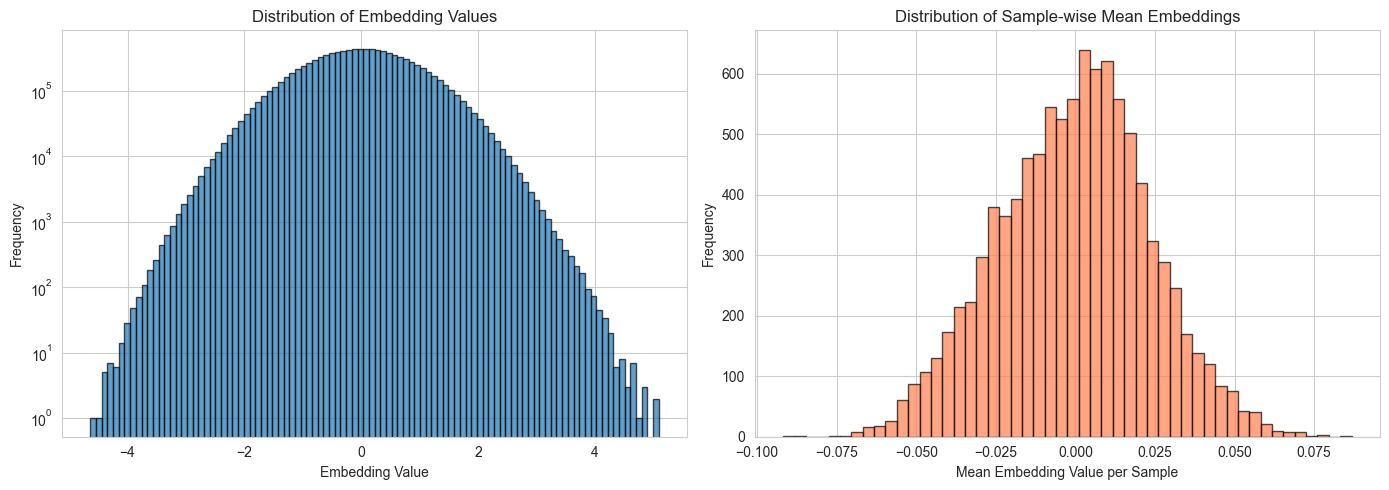

In [7]:
# Visualize embedding distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of values across all embeddings
axes[0].hist(emb_chunk_0.flatten(), bins=100, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Embedding Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Embedding Values')
axes[0].set_yscale('log')

# Mean embedding per sample
sample_means = emb_chunk_0.mean(axis=1)
axes[1].hist(sample_means, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Mean Embedding Value per Sample')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Sample-wise Mean Embeddings')

plt.tight_layout()
plt.show()

## 3. Explore HDF5 Spectra

HDF5 files contain the mass spectra data.

In [8]:
# Load first HDF5 file
hdf5_files = sorted((DATA_DIR / 'val_hdf5').glob('*.hdf5'))
print(f"Found {len(hdf5_files)} HDF5 files")

# Inspect first file
hdf5_path = hdf5_files[0]
print(f"\n📂 Inspecting: {hdf5_path.name}")

with h5py.File(hdf5_path, 'r') as f:
    print("\nKeys in HDF5 file:")
    for key in f.keys():
        print(f"  - {key}: {f[key].shape if hasattr(f[key], 'shape') else 'group'}")

Found 24 HDF5 files

📂 Inspecting: val_chunk_0000.hdf5

Keys in HDF5 file:
  - RT: (9996,)
  - charge: (9996,)
  - file_name: (9996,)
  - precursor_mz: (9996,)
  - scan_number: (9996,)
  - spectrum: (9996, 2, 128)


In [9]:
# Load and inspect spectrum data
with h5py.File(hdf5_path, 'r') as f:
    # Assuming structure - adjust based on actual keys
    if 'mz' in f.keys():
        mz = f['mz'][:]
        intensity = f['intensity'][:]
        print(f"Loaded spectrum data:")
        print(f"  m/z range: {mz.min():.2f} - {mz.max():.2f}")
        print(f"  Intensity range: {intensity.min():.2f} - {intensity.max():.2f}")
    else:
        # Explore what's actually in there
        print("\nExploring HDF5 structure:")
        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  Dataset: {name}, shape: {obj.shape}, dtype: {obj.dtype}")
        f.visititems(print_structure)


Exploring HDF5 structure:
  Dataset: RT, shape: (9996,), dtype: float64
  Dataset: charge, shape: (9996,), dtype: int64
  Dataset: file_name, shape: (9996,), dtype: object
  Dataset: precursor_mz, shape: (9996,), dtype: float64
  Dataset: scan_number, shape: (9996,), dtype: int64
  Dataset: spectrum, shape: (9996, 2, 128), dtype: float64


In [10]:
# Plot a sample spectrum (adjust based on actual structure)
# This is a placeholder - modify based on what you find above

with h5py.File(hdf5_path, 'r') as f:
    # Example: if spectra are stored as 2D array
    # spectrum_idx = 0
    # mz = f['mz'][spectrum_idx]
    # intensity = f['intensity'][spectrum_idx]
    
    # For now, let's try to find and plot first spectrum
    first_key = list(f.keys())[0]
    print(f"Attempting to visualize data from '{first_key}'")
    
    # Adjust this based on actual structure
    # plt.figure(figsize=(12, 5))
    # plt.stem(mz, intensity, linefmt='b-', markerfmt='bo', basefmt=' ')
    # plt.xlabel('m/z')
    # plt.ylabel('Intensity')
    # plt.title('Sample Mass Spectrum')
    # plt.grid(True, alpha=0.3)
    # plt.show()

Attempting to visualize data from 'RT'


## 4. Explore mzML Files (Optional)

mzML files are raw mass spectrometry data in XML format.

In [11]:
# List mzML files
mzml_files = sorted((DATA_DIR / 'val_conv').glob('*.mzML'))
print(f"Found {len(mzml_files)} mzML files")
print(f"\nFirst few files:")
for f in mzml_files[:5]:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  - {f.name}: {size_mb:.2f} MB")

Found 24 mzML files

First few files:
  - val_chunk_0000.mzML: 32.44 MB
  - val_chunk_0001.mzML: 30.67 MB
  - val_chunk_0002.mzML: 30.91 MB
  - val_chunk_0003.mzML: 30.24 MB
  - val_chunk_0004.mzML: 30.44 MB


In [ ]:
# To parse mzML files, you'd typically use pyteomics or pymzml
# Uncomment and install if needed:
# !pip install pyteomics

# Example parsing (if you install pyteomics):
# from pyteomics import mzml
# 
# with mzml.read(str(mzml_files[0])) as reader:
#     for idx, spectrum in enumerate(reader):
#         if idx == 0:  # First spectrum
#             print("First spectrum:")
#             print(f"  m/z array length: {len(spectrum['m/z array'])}")
#             print(f"  intensity array length: {len(spectrum['intensity array'])}")
#             break

## 5. Load All Embeddings (Optional)

If you want to work with all embeddings at once.

In [12]:
# Load all embedding chunks
def load_all_embeddings(emb_dir):
    """Load all .npy embedding files and concatenate."""
    emb_files = sorted(emb_dir.glob('*.npy'))
    embeddings = []
    
    for f in emb_files:
        emb = np.load(f)
        embeddings.append(emb)
        print(f"Loaded {f.name}: {emb.shape}")
    
    # Concatenate along first axis
    all_embeddings = np.concatenate(embeddings, axis=0)
    print(f"\n✅ Total embeddings shape: {all_embeddings.shape}")
    return all_embeddings

# Uncomment to load (may take time and memory):
# all_embeddings = load_all_embeddings(DATA_DIR / 'val_embs')

## 6. Dimensionality Reduction (UMAP/t-SNE)

Visualize the embedding space.

In [19]:
# Example: UMAP on first chunk
from umap import UMAP

# Subsample if too large
n_samples = min(1000, len(emb_chunk_0))
emb_subset = emb_chunk_0[:n_samples]

print(f"Running UMAP on {n_samples} samples...")
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(emb_subset)

print(f"✅ UMAP complete: {embedding_2d.shape}")

Running UMAP on 1000 samples...


/Users/wouterachterberg/coding/DreaMS/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP complete: (1000, 2)


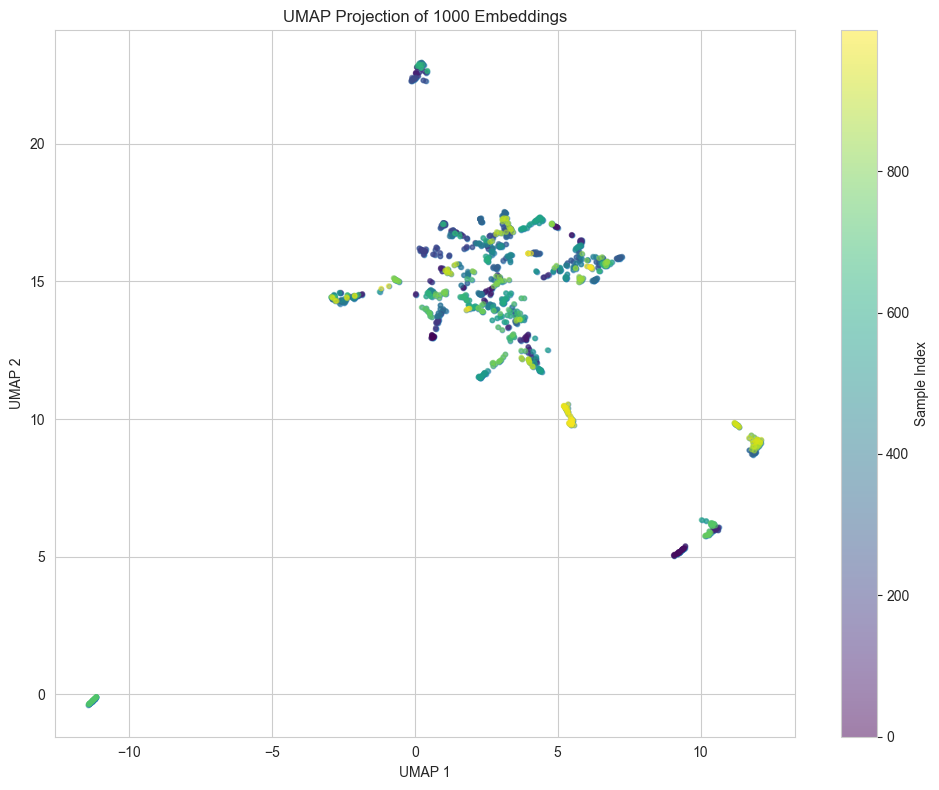

In [20]:
# Plot UMAP
plt.figure(figsize=(10, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.5, s=10)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP Projection of {n_samples} Embeddings')
plt.colorbar(plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                         c=np.arange(len(embedding_2d)), alpha=0.5, s=10, cmap='viridis'),
             label='Sample Index')
plt.tight_layout()
plt.show()

## Summary

Use this notebook to:
- ✅ Explore embedding files and their properties
- ✅ Inspect HDF5 spectra structure
- ✅ Check mzML file availability
- ✅ Visualize embedding distributions
- ✅ Perform dimensionality reduction

**Next Steps:**
- Link embeddings with metadata from your main dataset
- Compare embeddings across different chunks
- Analyze specific molecules or scaffolds